# Sliding Window Analysis (and general ENSO Characteristics)

Notebook for making basic visualizations of ENSO (and other timeseries).

Contents

1. Load Nino3.4 Indices from netCDF
2. Monthly Standard Deviation
3. Nino3.4 Power Spectrum
4. Sliding Window Standard Deviation and Persistence

by Glenn Liu, 2026.02.19


In [1]:
import sys
import time
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
import xarray as xr
import sys
import tqdm
import glob 
import scipy as sp
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import calendar as cal


In [2]:
# Functions copied from Sen Zhao's XRO code for spectral analysis
# https://github.com/senclimate/XRO/blob/main/XRO/stats.py
# Modification was made to remove lag1_r from xr.apply_ufunc

def pmtm(ds_x, dim='time', dt=1/12., nw=4, cl=0.95, nfft=None, scale_by_freq=True, lag1_r=None,
         return_dataset=False):
    """
    Thomson’s multitaper power spectral density (PSD) estimate, 
    PSD significance level estimate, Confidence Intervals

    PSD estimate modified from Peter Huybers's matlab code, pmtmPH.m
    PSD significance level estimate modified from NCAR/NCL specx_ci 

    Parameters
    ----------
    x : numpy array
        Time series to analyze
    dt : float
        Sampling interval, default is 1.
    nw : float
        The time bandwidth product, available 
    cl : float
        Confidence interval to calculate and display
    nfft: int
        Default 
    lag1_r: float
        significance test for AR(1) lag1_r value
    return_dataset: True or False
        return xarray dataset

    Returns
    -------
    x_P : xarray DataArray
        PSD estimate via the multi-taper method.
    x_P_sig : xarray DataArray
        PSD significance level estimate.
    x_ci : xarray DataArray
        Confidence intervals.
    """
    P_ds, s_ds, Psig_ds, ci_ds = xr.apply_ufunc(_pmtm, ds_x, input_core_dims=[[dim]],
                             output_core_dims=[['freq'], ['freq'], ['freq'], ['freq', 'bound', ]],
                             kwargs={'dt': dt, 'nw': nw, 'cl': cl,
                                     'nfft': nfft, 'scale_by_freq': scale_by_freq,},
                             vectorize=True)
    if len(s_ds.dims)==1:
        P_ds = P_ds.assign_coords({'freq': s_ds})
        Psig_ds = Psig_ds.assign_coords({'freq': s_ds})
        ci_ds = ci_ds.assign_coords({'freq': s_ds})
    else:
        mem_dim = list(s_ds.dims)[0]
        P_ds = P_ds.assign_coords({'freq': s_ds.isel({mem_dim: 0}).values})
        Psig_ds = Psig_ds.assign_coords({'freq': s_ds.isel({mem_dim: 0}).values})
        ci_ds = ci_ds.assign_coords({'freq': s_ds.isel({mem_dim: 0}).values})

    if return_dataset:
        out_ds = xr.Dataset({'P': P_ds, 'Psig': Psig_ds, 'Pci': ci_ds})
        out_ds.attrs['dt'] = dt
        out_ds.attrs['nw'] = nw
        out_ds.attrs['cl'] = cl
        out_ds.attrs['scale_by_freq'] = scale_by_freq
        return out_ds
    else:
        return P_ds, Psig_ds, ci_ds

def _pmtm(x, dt=1, nw=4, cl=0.95, nfft=None, scale_by_freq=True):
    '''
        numpy of pmtm
    '''

    from scipy.signal import windows
    from scipy.stats import chi2

    if nfft is None:
        nfft = np.shape(x)[0]

    nx = np.shape(x)[0]
    k = min(np.round(2.*nw), nx)
    k = int(max(k-1, 1))
    s = np.arange(0, 1/dt, 1/(nfft*dt))

    # Compute the discrete prolate spheroidal sequences
    [E, V] = windows.dpss(nx, nw, k, return_ratios=True)
    E = E.T

    # Compute the windowed DFTs.
    Pk = np.abs(np.fft.fft(E*x[:, np.newaxis], nfft, axis=0))**2

    # Iteration to determine adaptive weights
    if k > 1:
        sig2 = np.dot(x[np.newaxis, :], x[:, np.newaxis])[0][0]/nx # power
        # initial spectrum estimate
        P = ((Pk[:, 0] + Pk[:, 1])/2)[:, np.newaxis]
        Ptemp = np.zeros((nfft, 1))
        P1 = np.zeros((nfft, 1))
        tol = .0005*sig2/nfft
        a = sig2*(1-V)

        while (np.sum(np.abs(P - P1)/nfft) > tol):
            b = np.repeat(P, k, axis=-1)/(P*V[np.newaxis, :] + np.ones((nfft, 1))*a[np.newaxis, :])
            wk = (b**2) * (np.ones((nfft, 1))*V[np.newaxis, :])
            P1 = (np.sum(wk*Pk, axis=-1)/np.sum(wk, axis=-1))[:, np.newaxis]

            Ptemp = np.empty_like(P1)
            Ptemp[:] = P1
            P1 = np.empty_like(P)
            P1[:] = P
            P = np.empty_like(Ptemp)
            P[:] = Ptemp

        # Determine equivalent degrees of freedom, see Percival and Walden 1993.
        v = ((2*np.sum((b**2)*(np.ones((nfft, 1))*V[np.newaxis, :]), axis=-1)**2) /
             np.sum((b**4)*(np.ones((nfft, 1))*V[np.newaxis, :]**2), axis=-1))

    else:
        P = np.empty_like(Pk)
        P[:] = Pk
        v = 2*np.ones((nfft, 1))

    select = (np.arange(0, (nfft + 1)/2.)).astype('int')
    P = P[select].flatten()
    s = s[select].flatten()
    v = v[select].flatten()

    # Whether the resulting density values should be scaled by the scaling frequency, which gives density in units of 1/day, 1/year, or 1/Hz.
    # This allows for integration over the returned frequency values
    if scale_by_freq:
        P *= dt
    
    # Chi-squared 95% confidence interval
    # approximation from Chamber's et al 1983; see Percival and Walden p.256, 1993
    ci = np.empty((np.shape(v)[0], 2))
    ci[:, 0] = 1./(1-2/(9*v) - 1.96*np.sqrt(2/(9*v)))**3
    ci[:, 1] = 1./(1-2/(9*v) + 1.96*np.sqrt(2/(9*v)))**3
    
    # red noise significance levels
    # PSD significance level estimate modified from NCAR/NCL specx_ci 
    alpha = np.corrcoef(x[:-1], x[1:])[0, 1]
    dof = v
    P_red = (1 - alpha**2) / (1 + alpha**2 - 2 * alpha * np.cos(2 * np.pi * s * dt))
    # rescale
    scale = np.sum(P)/np.sum(P_red)
    quantile = chi2.ppf(cl, dof)
    P_sig = P_red * scale * quantile / dof
 
    x_s = xr.DataArray(s, dims=['freq'], coords={'freq': s})
    x_P = xr.DataArray(P, dims=['freq'], coords={'freq': s})
    x_P_sig = xr.DataArray(P_sig, dims=['freq'], coords={'freq': s})
    x_ci = xr.DataArray(ci, dims=['freq', 'bound'], coords={'freq': s, 'bound': [0, 1]})
    return x_P, x_s, x_P_sig, x_ci


# Loading Required Datasets

To run this script:

1. Indicate path to directory containing the ENSO indices with the variable `ensopath`, and optionally declare the name using `ensoid_name`. To simplify things, I've provided pre-calculated indices at this google drive link: https://drive.google.com/drive/folders/12uwQzob-3b4HYPuug61czeSdxmw38Fhj?usp=drive_link

2. Modify `expnames` to indicate which experiments/model runs you want to visualize and the `expcolors` to set the line color.

Note: This cell can be skipped/replaced, as long as the output is a list of ENSO indices (`enso_indices`) contained in `xr.DataArrays` with the dimension `time` and corresponding `expnames` and `expcolors`.

In [3]:
# Load a NetCDF containing standardized ENSO index and the standard deviation

# Indicate Experiment Names
expnames          = ["TCo95-hi1950d", # 0
                     "TCo95-ssp585d", # 1
                     "TCo319-DART-ctl1950d-gibbs-charn", # 2
                     "TCo319-DART-ssp585d-gibbs-charn", # 3
                     "TCo1279-DART-1950",  # 4
                     "TCo1279-DART-2060",  # 5
                     "TCo1279-DART-2090",  # 6
                     "TCo2559-DART-1950C", # 7
                     "EC-Earth3", # 8
                     "E3SM-1-0", # 9
                     "E3SM-1-1", # 10
                     "E3SM-1-1-ECA", # 11
                     "ERA5_1979_2024",] # 12

# Set Experiment Colors for plots               
expcolors         = ["lightgray",
                     "hotpink",
                     "grey",
                     "salmon",
                     "royalblue",
                     "violet",
                     "firebrick",
                     "darkslateblue",
                     "limegreen",
                     "cyan",
                     "midnightblue",
                     "magenta",
                     "k"] # Color Associated with each experiment


# Set paths to ENSO Indices and other Files
# Note: may need to modify [enso_nc] if your naming convention is different...
ensopath          = "/home/niu4/gliu8/projects/scrap/nino34/" # (!!) Set Path to ENSO Indices
ensoid_name       = "nino34" # Name of ENSO Index
standardize       = False    # Set to True to return standardized ENSO Indices

# Load the Files
nexp         = len(expnames)
enso_indices = []
for ex in range(nexp): 
    expname           = expnames[ex]    
    enso_nc           = "%s%s_%s.nc" % (ensopath,expname,ensoid_name) # ex: <path_to_file>/TCo1279-DART-2060_nino34.nc
    print("Loading the following file: %s" % enso_nc)

    ds = xr.open_dataset(enso_nc).load()
    
    if standardize is False: # The provided indices were standardized by the value 'std'
        ds = ds.sst * ds['std']
    else:
        ds = ds.sst

    enso_indices.append(ds)

Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/TCo95-hi1950d_nino34.nc
Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/TCo95-ssp585d_nino34.nc
Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/TCo319-DART-ctl1950d-gibbs-charn_nino34.nc
Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/TCo319-DART-ssp585d-gibbs-charn_nino34.nc
Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/TCo1279-DART-1950_nino34.nc
Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/TCo1279-DART-2060_nino34.nc
Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/TCo1279-DART-2090_nino34.nc
Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/TCo2559-DART-1950C_nino34.nc
Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/EC-Earth3_nino34.nc
Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/E3SM-1-0_nino34.nc
Loading the following file: /home/niu4/gliu8/

Converting to datetimeindex for E3SM-1-0
Converting to datetimeindex for E3SM-1-1
Converting to datetimeindex for E3SM-1-1-ECA


/tmp/ipykernel_2109736/2957413096.py:21: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ax.plot(plotvar.indexes['time'].to_datetimeindex(),plotvar,label=expnames[ex],c=expcolors[ex])
/tmp/ipykernel_2109736/2957413096.py:21: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ax.plot(plotvar.indexes['time'].to_datetimeindex(),plotvar,label=expnames[ex],c=expcolors[ex])


Text(0.5, 0.01, 'Time')

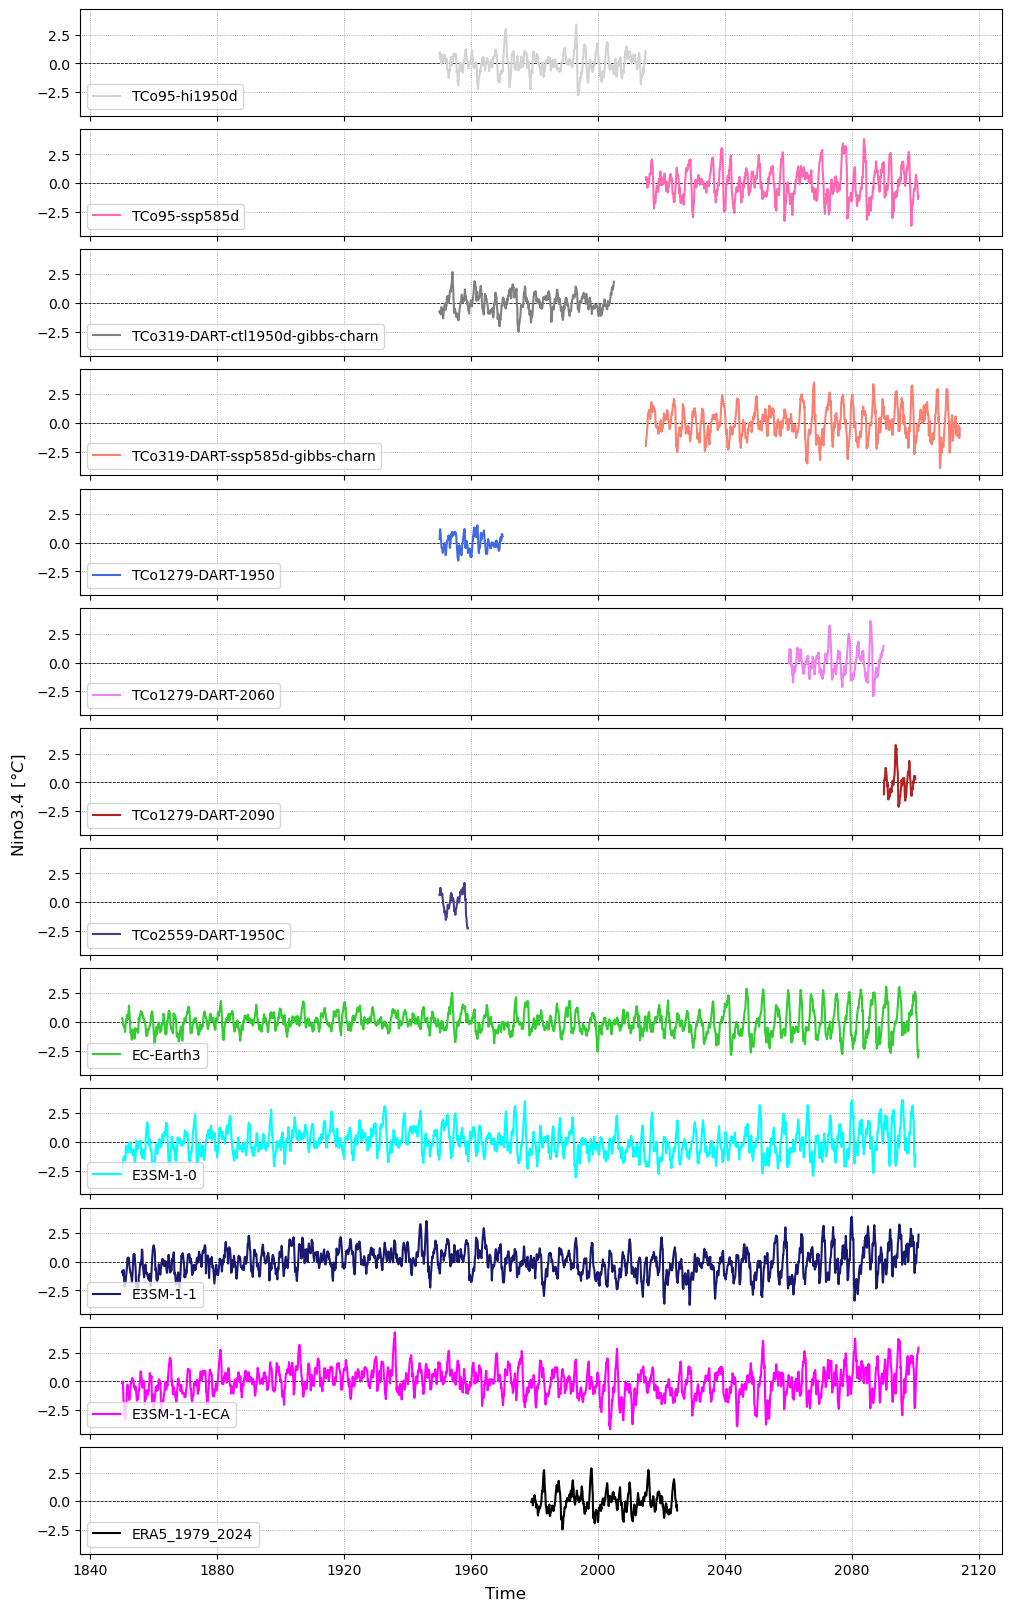

In [61]:
# Plot timeseries to check

fig,axs= plt.subplots(nexp,1,sharey=True,sharex=True,
                      constrained_layout=True,figsize=(10,16))

convert_datetime = [] # Store experiments where datetime needs to be converted for plotting, for sliding analysis
for ex in range(nexp):
    # Set up Axes
    ax = axs[ex]
    ax.axhline([0],ls='dashed',c='k',lw=0.55)
    ax.grid(True,ls='dotted',lw=0.5,c='gray')

    # Convert to DateTimeIndex for some of the other model outputs if necessary, then plot
    plotvar = enso_indices[ex]
    try:
        ax.plot(plotvar.time,plotvar,label=expnames[ex],c=expcolors[ex])
    except: 
        print("Converting to datetimeindex for %s" % expnames[ex])
        convert_datetime.append(ex) # Store to convert later
         # Convert to DateTimeIndex
        ax.plot(plotvar.indexes['time'].to_datetimeindex(),plotvar,label=expnames[ex],c=expcolors[ex])
    
    # Indicate Experiment/Model run in Legend
    ax.legend(loc='lower left')
    
# Labeling
fig.supylabel(r"Nino3.4 $[\degree C]$")
fig.supxlabel("Time")


# Figure: Monthly Standard Deviation

Similar to Moon et al. 2025 Figure 17 Panels f-h

1. Compute standard deviation for anomalies of each month.
2. Visualize output as bar plot.

This plot was modified to match the style in Stuecker et al. 2025, Supplementary Figure 12a.

In [15]:
%%time
# Calculate Monthly Standard Deviation
monthly_stdev = [ds.groupby('time.month').std('time') for ds in enso_indices]

CPU times: user 75.5 ms, sys: 2 ms, total: 77.5 ms
Wall time: 77 ms


CPU times: user 2.56 s, sys: 4.01 ms, total: 2.57 s
Wall time: 2.59 s


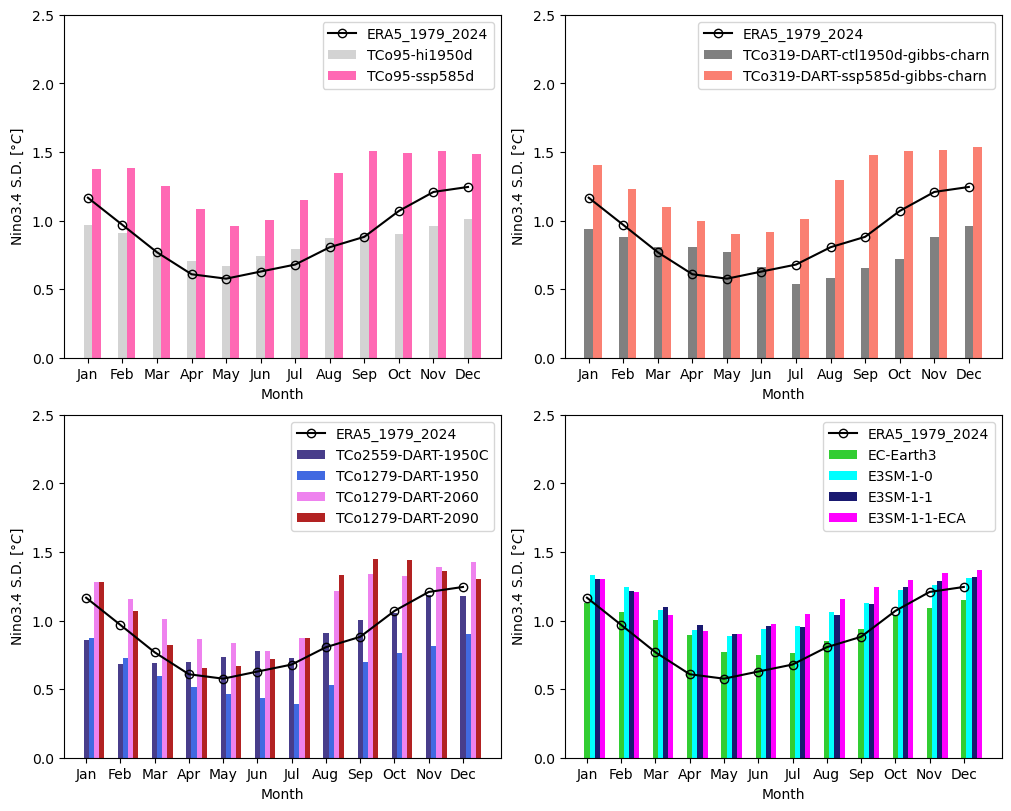

In [19]:
%%time
# Monthly SD Plots in the style of Moon et al. 2025...

# Plotting Options
x            = np.arange(12)      # the label locations
plotex       = [0,1,2,3,4]        # Indices of Experiments to plot
mons3        = [cal.month_name[i][:3] for i in np.arange(1,13,1)] # Months for Labeling
label_bars   = False
refex        = expnames.index("ERA5_1979_2024") # Index of Observation/Reanalysis Reference, plotted on all subplots

# Initialize Figure (Modify [plotexs] to accomodate the number of sets and which experiments to compare)
# Each set indicates which experiments on plotted on a given subplot
plotexs     = [[0,1],[2,3],[7,4,5,6],[8,9,10,11]]
nset        = len(plotexs)
fig,axs     = plt.subplots(2,2,layout='constrained',figsize=(10,8))

# Loop for each Month
for iset in range(nset):
    plotex = plotexs[iset]
    ax = axs.flatten()[iset]
    
    # Adjust the Width of the bars based on number of experiments in each set.
    # This is hard coded, but can modify this
    number_to_plot = len(plotex)
    if number_to_plot < 3:
        width        = 0.25           # the width of the bars
    else:
        width        = 0.15
    
    multiplier = 0
    for im in range(12):
        offset = width * multiplier
    
        # Loop for each Experiment
        for ii in range(len(plotex)):
            
            # Setup
            ex          = plotex[ii]
            offset      = width * ii
            color_in    = expcolors[ex]
            expid       = plotex[ii]
            if im == 0: # Label onlyon first iteration
                label=expnames[expid]
            else:
                label=""
            
            # Get Data and PLot
            measurement = monthly_stdev[expid].data
            rects  = ax.bar(x + offset, measurement, width, label=label,
                            color=color_in,linewidth=0.5)
            
            # Set Axis Ticks and option to label bars
            ax.set_xticks(x,mons3)
            if label_bars:
                ax.bar_label(rects, padding=3,fmt="%.02f")
            multiplier += 1
    
        

    # Also Plot Observations
    plotvar = monthly_stdev[refex]
    ax.plot(mons3,plotvar,c='k',marker="o",fillstyle='none',label=expnames[refex])


    # Axis Labeling and Legend
    ax.set_ylabel(r"Nino3.4 S.D. [$\degree C$]")
    ax.set_xlabel("Month")
    ax.set_ylim([0,2.5])
    ax.legend()

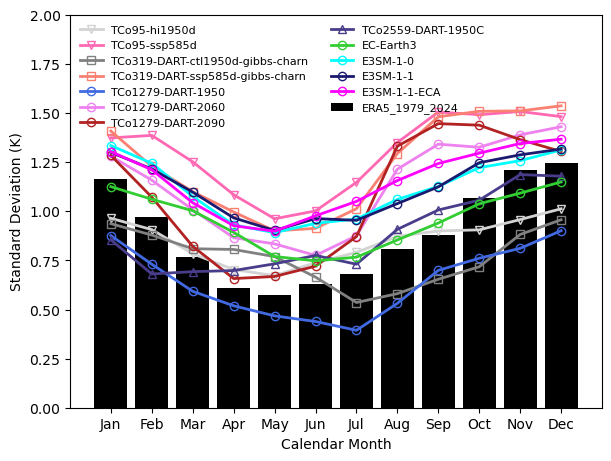

In [70]:
# Make Combined Plot of Monthly Stdev., Akin to Supplemental Figure 12 A.

# Plotting Options
x            = np.arange(12)  # the label locations
width        = 0.25           # the width of the bars
refex        = expnames.index("ERA5_1979_2024") # Reference Variable to plot as bars (usually observations  or reanalysis)
mons3        = [cal.month_name[i][:3] for i in np.arange(1,13,1)] # Months for Labeling
label_bars   = False
ymax         = 2 # Maximum of y axis

# Other Edits

# Initialize Figure
fig,ax       = plt.subplots(1,1,layout='constrained',figsize=(6,4.5))

for ex in range(nexp):

    plotvar  = monthly_stdev[ex].data
    label    = expnames[ex]
    color_in = expcolors[ex]


    if "TCo95" in label:
        mks = "v"
    elif "TCo319" in label:
        mks = "s"
    elif "TCo1279" in label:
        mks = "o"
    elif "TCo2559" in label:
        mks = "^"
    else:
        mks = "o"
    
    # Plot Bars if Reference Variable
    if ex == refex:
        rects   = ax.bar(mons3, plotvar, label=label,
                            color=color_in)
    else:
        ax.plot(mons3,plotvar, label=label,
                            color=color_in,linewidth=2,fillstyle="none",marker=mks)

ax.set_xticks(x,mons3)
ax.set_ylim([0,ymax])
ax.set_ylabel("Standard Deviation (K)")
ax.set_xlabel("Calendar Month")
ax.legend(fontsize=8,ncol=2,frameon=False)

# Calculate and Visualize Nino3.4 Power Spectra

Based on the notebook `RO_practical_with_CRO_framework.ipynb`
https://github.com/senclimate/RO_practical/blob/main/CRO_test/RO_practial_with_CRO_framework.ipynb
by Sen Zhao and Soong-Ki Kim

Uses the "pmtm" function from Sen Zhao's XRO utilities (XRO/stats.py)
https://github.com/senclimate/XRO

This plot was modified to match the style in Stuecker et al. 2025, Supplementary Figure 12b.

Note: Data length for some of the simulations is quite short (TCo1279 and TCo2559 simulations)

In [20]:
# For Each Index, Compute the Power Spectrum using the Multi-Taper Method
psd_byexp     = []
psd_sig_byexp = []
for ex in range(nexp):
    index_in                 = enso_indices[ex]
    psd, psd_sig, psd_ci_obs = pmtm( index_in, dim='time', dt=1/12, nw=5)
    psd_byexp.append(psd)
    psd_sig_byexp.append(psd_sig)

Text(0.5, 1.0, 'Niño3.4 SSTA Power Spectrum')

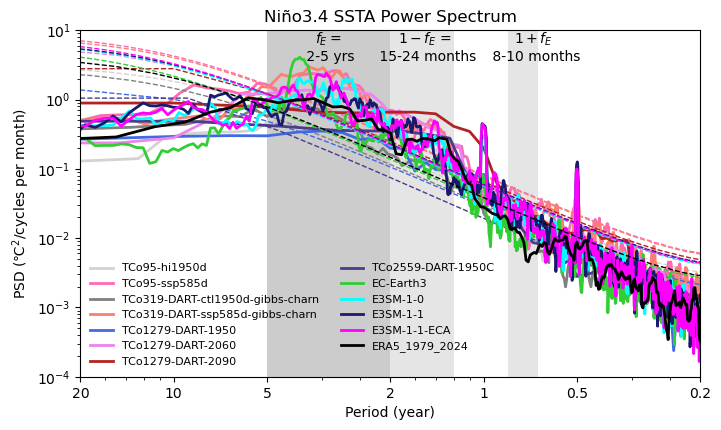

In [22]:

lw = 2 # Indicate Line Width for the spectra

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))

for ex in range(nexp):

    psd = psd_byexp[ex]
    psd_sig = psd_sig_byexp[ex]
    color_in = expcolors[ex]
    lab = expnames[ex]
    
    ax.loglog(psd.freq, psd, lw=lw, color=color_in, label=lab)
    ax.plot(psd_sig.freq, psd_sig, lw=1., color=color_in, linestyle='--', label='')

# Initialize Plot
per = [50,20,10,5,2,1,0.5,0.2]
xt = 1.0/np.array(per)
ax.set_xticks(xt)
ax.set_xticklabels(map(str, per))
ax.set_ylabel('PSD (℃$^2$/cycles per month)')
ax.set_xlabel('Period (year)')
ax.set_xlim([1/20, 5])
ax.set_ylim([1e-4, 10])

ax.legend(ncol=2,frameon=False,fontsize=8)

y_min, y_max = ax.get_ylim()
#Mfreq_enso = np.array([1/2.5, 1/5.5])
Mfreq_enso = np.array([1/2, 1/5])
Mfreq_fplus = 1 + Mfreq_enso
Mfreq_fmins = 1 - Mfreq_enso

ax.fill_between(Mfreq_enso, y_min, y_max, fc='gray', alpha=0.4)
ax.fill_between(Mfreq_fplus, y_min, y_max, fc='gray',  alpha=0.2)
ax.fill_between(Mfreq_fmins, y_min, y_max, fc='gray', alpha=0.2)

#ax.text(np.mean(Mfreq_enso)*0.9, y_max, '$f_{E}=$\n 2.5-5.5 yrs', ha='center', va='top')
ax.text(np.mean(Mfreq_enso)*0.9, y_max, '$f_{E}=$\n 2-5 yrs', ha='center', va='top')
ax.text(np.mean(Mfreq_fplus)+0.1, y_max, '$1+f_{E}$\n 8-10 months', ha='center', va='top')
ax.text(np.mean(Mfreq_fmins), y_max, '$1-f_{E}$ = \n 15-24 months', ha='center', va='top')
ax.set_title('Niño3.4 SSTA Power Spectrum')

# Running Window Analysis for Standard Deviation and Persistence

1. Subset timeseries to N-year segments using running windows
2. Calculate standard deviation and persistence (lag-1 autocorrelation) for each segment.
3. Visualize the output

In [26]:
# Define Functions

def get_moving_segments(ts,winlen):
    '''
    Divide timeseries into segments using a sliding window of [winlen] months.
    
    Inputs
        ts (xr.DataArray)      : Target timeseries, with time dimension
        winlen (int)           : Number of months in sliding window
    Outputs
        ts_segments (np.array) : Sliding segments with dimensions  [segment_number,winlen]
        center_time (np.array) : Center time of the sliding window [segment_number]

    '''
    # Get Timeseries length and compute maximum number of segments
    ntime = len(ts)
    nsegments = ntime - winlen + 1
    
    # Take Segments
    ts_segments = np.zeros((nsegments,winlen))
    center_time = []#np.zeros((nsegments))
    for i in range(nsegments):
        idseg = np.arange(i,i+winlen)
        ts_segments[i,:] = ts[idseg]
        center_time.append(ts.time.isel(time=int(i+ int(winlen/2))))
    # Concatenate center timesteps
    center_time = xr.concat(center_time,dim='time')
    return ts_segments,center_time

In [27]:
# (1)-(2) Subset into Segments, Take Moving Standard Deviation and Persistence

winlen_default       = 21*12
winlen_short         = 5*12 # Shorter window length for runs where nyrs < 21
r1s          = []
stdevs       = [] 
ctimes_byexp = []
winlen_used  = []
for ex in tqdm.tqdm(range(nexp)):
    ts              = enso_indices[ex]
    if len(ts) > winlen_default:
        winlen = winlen_default
    else:
        winlen = winlen_short
    winlen_used.append(winlen)
    
    segments,ctimes = get_moving_segments(ts,winlen)

    nsegments,ntime = segments.shape
    r1exp=[]
    for nn in range(nsegments):
        r = np.corrcoef(segments[nn,:(ntime-1)],segments[nn,1:])[0,1]
        r1exp.append(r)
    r1s.append(np.array(r1exp))
    stdevs.append(np.std(segments,1))
    ctimes_byexp.append(ctimes)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:11<00:00,  1.17it/s]


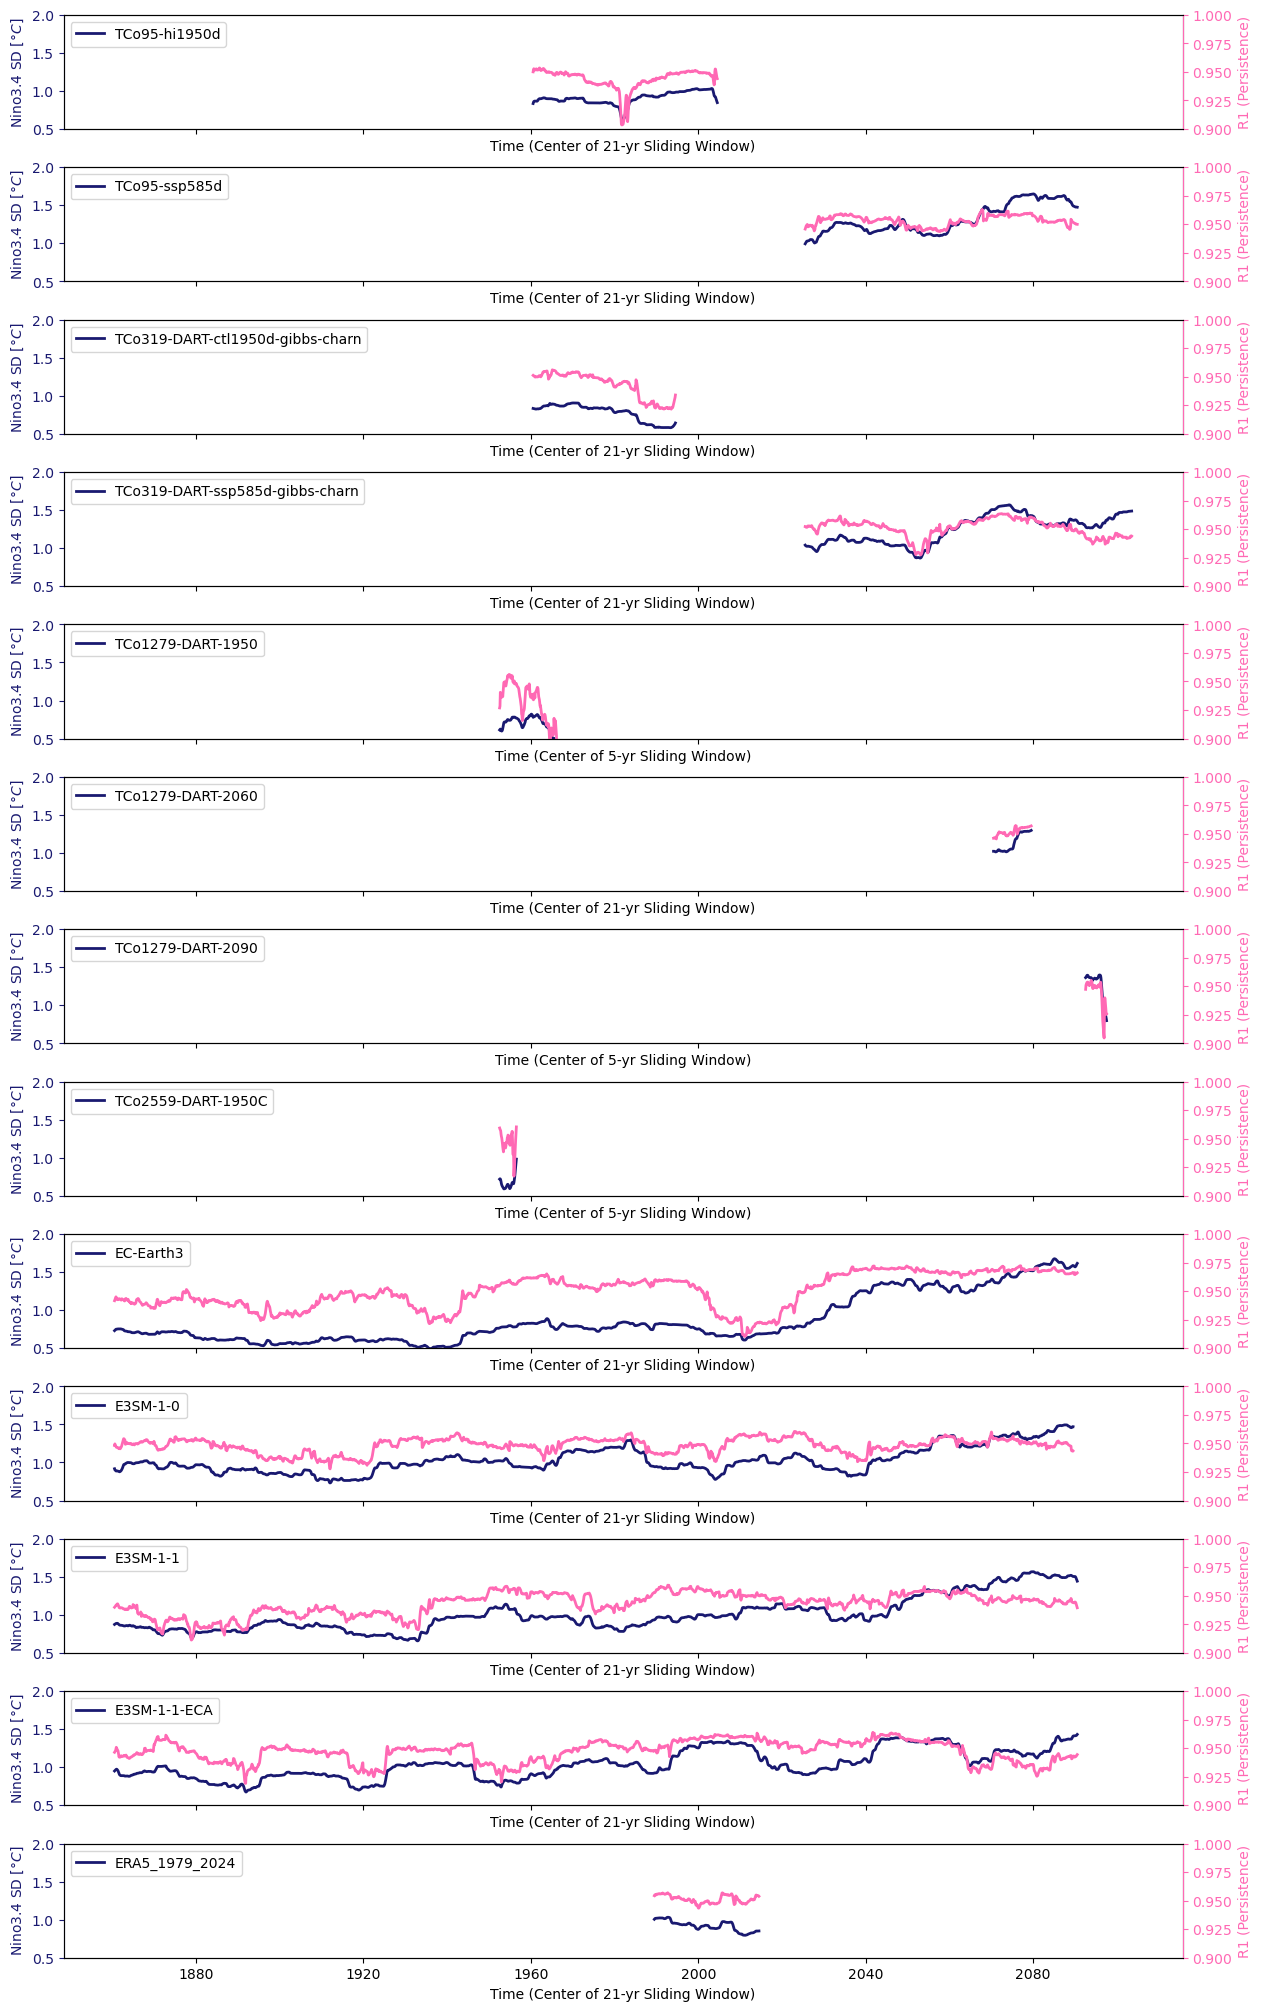

In [69]:
# Plot Sliding Standard Deviation and R1

# Indicate Colors
r1col   = 'hotpink'
sdcol   = 'midnightblue'

# Make Plot
fig,axs = plt.subplots(nexp,1,figsize=(12.5,20),constrained_layout=True,sharex=True,)

for ii in range(nexp):
    ax      = axs[ii]
    ex      = ii
    
    plotvar = stdevs[ii]
    ctime   = ctimes_byexp[ii]
    if np.isin(ex,convert_datetime):
        ctime = [np.datetime64(tt) for tt in ctime.dt.strftime("%Y-%m-%d").data]

    
    ax.plot(ctime,plotvar,label=expnames[ex],lw=2,color=sdcol)

    ax2 = ax.twinx()
    plotvar2 = r1s[ii]
    ax2.plot(ctime,plotvar2,color=r1col,lw=2)
    ax2.set_ylim([.90,1.0])
    ax2.set_ylabel("R1 (Persistence)")
    
    ax2.tick_params(axis='y',colors=r1col)
    ax2.spines['right'].set_color(r1col)
    ax2.yaxis.label.set_color(r1col)
    
    
    ax.legend(loc='upper left')
    ax.set_ylim([0.5,2])
    ax.set_ylabel(r"Nino3.4 SD [$\degree C$]")

    ax.tick_params(axis='y',colors=sdcol)
    ax.spines['left'].set_color(sdcol)
    ax.yaxis.label.set_color(sdcol)
    #if ii == 2:
    ax.set_xlabel("Time (Center of %i-yr Sliding Window)" % (winlen_used[ii]/12))
